Harika! Artık **Kernel PCA (Çekirdekli PCA)** bölümüne geçiyorsun ve bu, klasik PCA’nın **doğrusal olmayan** (non-linear) versiyonudur.
Aşağıda sana konuyu sade bir dille, örneklerle ve diğer tekniklerle farklarını da belirterek anlatacağım:

---

## 🧠 Kernel PCA Nedir?

> **Kernel PCA**, klasik PCA’nın çalışamadığı karmaşık ve doğrusal olmayan (non-linear) veri yapıları için geliştirilmiş bir boyut indirgeme yöntemidir.

### 🔁 Hatırlayalım: Klasik PCA ne yapıyordu?

* Yüksek boyutlu veride **en yüksek varyansa sahip doğrusal eksenleri** bulup, o eksenlere göre boyut indiriyordu.
* Ancak bu sadece **doğrusal (lineer) yapıları** algılayabiliyordu.

> Ama gerçek hayatta veriler genelde doğrusal değil, karmaşık bir eğriler kümesi şeklindedir.

📌 İşte burada devreye **Kernel PCA** giriyor!

---

## 🔍 Kernel PCA Ne Yapar?

1. **Veriyi yüksek boyutlu bir uzaya (feature space)** dönüştürür.
2. Bu uzayda artık veriler **doğrusal hale gelmiş gibi** olur.
3. Klasik PCA bu dönüştürülmüş uzayda çalıştırılır.

> Yani veri "eğri" olsa bile, **çekirdek fonksiyonlarıyla** düzleştirilmiş gibi davranırız.

---

## 📌 Kernel PCA – PCA Farkı

| Özellik                        | PCA                                | Kernel PCA                         |
| ------------------------------ | ---------------------------------- | ---------------------------------- |
| Lineer mi?                     | Evet (sadece düz çizgisel yapılar) | Hayır (karmaşık eğrileri de çözer) |
| Kernel kullanır mı?            | Hayır                              | Evet                               |
| Varyansı maksimize eder        | ✅                                  | ✅ (çekirdek uzayında)              |
| Non-lineer veri için uygundur  | ❌                                  | ✅                                  |
| Etiket gerekmez (unsupervised) | ✅                                  | ✅                                  |

---

## 🧪 Hangi Kernel Türleri Kullanılır?

Kernel PCA’da aşağıdaki çekirdek fonksiyonları kullanılabilir:

| Kernel Tipi          | Açıklama                                                     |
| -------------------- | ------------------------------------------------------------ |
| **Linear**           | Normal PCA gibi davranır                                     |
| **Polynomial**       | Çok terimli ilişkileri modelleyebilir                        |
| **RBF (Gaussian)** ✅ | En çok kullanılan! Karmaşık, eğri şekilleri ayırmada çok iyi |
| **Sigmoid**          | Nadir kullanılır                                             |

### En çok kullanılan: `kernel='rbf'`

---

## 📈 Uygulama Alanları

* **Veri görselleştirme**: Karmaşık veri kümelerini 2D/3D'ye indirip görselleştirme
* **Yüz tanıma**: Doğrusal olmayan varyasyonları ayrıştırma
* **Sınıflandırma**: Kernel PCA + Lojistik Regresyon / SVM kombinasyonu
* **Anomali tespiti**: Olağan dışı örnekleri ayırmada etkili

---

## 🎨 Görsel Analojisi

Hayal et:

* Veriler çember şeklinde dağılmış (örn: iç içe halkalar)
* Klasik PCA hiçbir şekilde bu çemberleri ayıramaz çünkü hepsi aynı varyansa sahiptir.
* Ama **Kernel PCA**, bu çemberleri 3D uzaya “eğip” ayırabilir.

Tıpkı aşağıdaki gibi:

```text
2D Uzayda:                3D Uzaya çekince:
     ○                             ↑       ↑
    ○○○     --> Kernel PCA -->   ○       ○
   ○○○○○                         ↑       ↑
     ○
```

---

## ✅ Kernel PCA Nerelerde Kullanılır?

* Etiket olmadan (unsupervised) **karmaşık desenleri** ayırmak istediğinde
* Klasik PCA işe yaramadığında (veri doğrusal değilse)
* Sınıflandırma için daha ayrıştırıcı özellikler (features) üretmek gerektiğinde

---

## 💬 Özetle

| Soru                                       | Cevap                                                |
| ------------------------------------------ | ---------------------------------------------------- |
| PCA doğrusal olmayan veriyi ayırabilir mi? | ❌ Hayır                                              |
| Kernel PCA ne yapar?                       | Veriyi daha yüksek boyutlu uzaya dönüştürerek ayırır |
| Etiketli veri gerekir mi?                  | ❌ Gerekmez (unsupervised)                            |
| Hangi kernel en sık kullanılır?            | ✅ RBF (Gaussian)                                     |
| Kernel PCA sonrası ne yapılır?             | Görselleştirme, sınıflandırma, anomali tespiti       |

---

Hazırsan şimdi Kernel PCA eğitim videosuna geçebilirsin.
Bitirdiğinde, **PCA - LDA - Kernel PCA** karşılaştırması, kod örnekleri veya pratik uygulamalar için tekrar birlikte çalışabiliriz.

Devam edebilirsin, ben buradayım!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Wine.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Applying Kernel PCA

In [5]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components = 2, kernel = 'rbf')
X_train = kpca.fit_transform(X_train)
X_test = kpca.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]


1.0

C:\Users\523579\AppData\Local\Temp\ipykernel_30832\3318974776.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


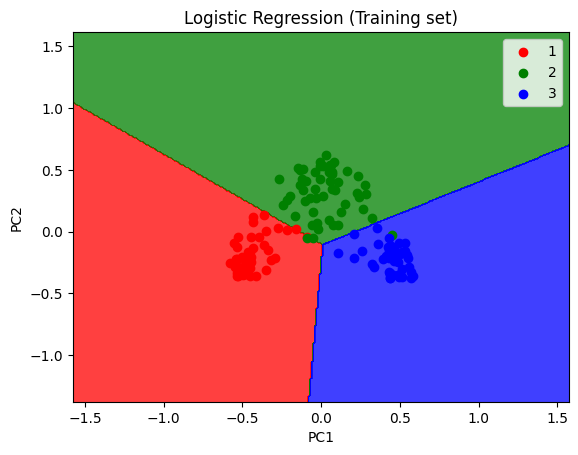

In [8]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

C:\Users\523579\AppData\Local\Temp\ipykernel_30832\3946207957.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


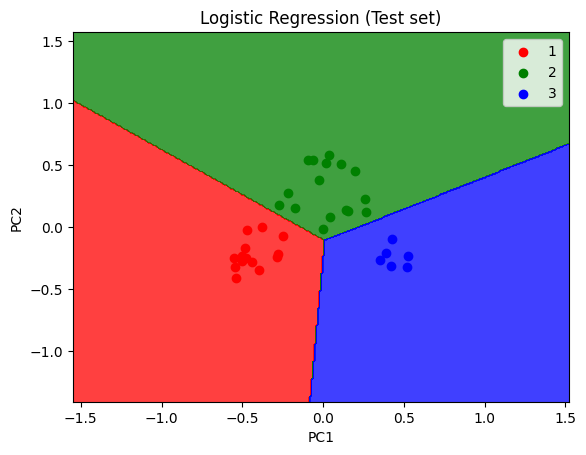

In [9]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()